In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

class Radar:
    def __init__(self,
                 f,
                 ins_info,
                 out_info,
                 z, 
                 thick,
                 r,
                 d,
                 dp,
                 mrf,
                 t,
                 pha,
                 l):
        
        self.input_filename  = f
        self.instrument_info = ins_info
        self.output_info     = out_info
        self.height          = z
        self.thickness       = thick
        self.reff            = r
        self.dist            = d
        self.distparam       = dp
        self.max_rad_factor  = mrf
        self.temp            = t
        self.phase           = pha
        self.lwc             = l
        
        self.system_info = [ins_info, out_info]
        self.cloud_info  = np.concatenate(([z],
                                 [thick], 
                                 [r],
                                 [d], 
                                 [dp],
                                 [mrf],
                                 [t],
                                 [pha],
                                 [l]), axis=0).transpose()
    def write_input(self):
        # instrument and output information:
        lines = []
        for lin in self.system_info:
            lines.append('\t'.join(map(str, lin)))

        # cloud information 
        for i in range(self.cloud_info.shape[0]):
            lines.append('\t'.join(self.cloud_info[i,:]))
        
        with open(self.input_filename, 'w') as f:
            for line in lines:
                f.write(line)
                f.write('\n')
    
    def run(self, out_filename):
        os.system("ssradar "+ self.input_filename + ">" + out_filename) # it works because the output
                                                                        # is a .txt file
        
    def get_output(self, path):
        return np.loadtxt(path, skiprows=8)
        

## First example of ssradar libradtran

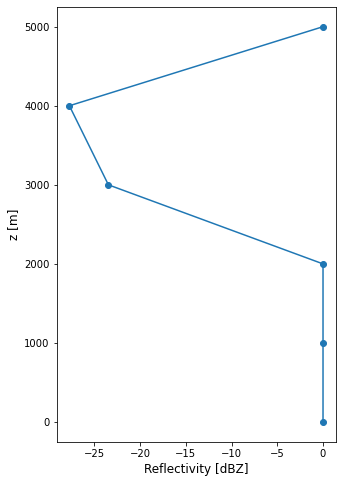

In [4]:
PATH_FIG = "../figures/"
PATH_INP = "../../ssradar_inp/"
PATH_OUT = "../../ssradar_out/"

def main():
    instrument_info = np.array([8.5, 0.0, 0.0, 0.0], float)
    output_info     = np.array([6, 1000.0, 0.0, -1], float)

    height          = np.array([1000.0, 2000.0, 3000.0, 4000.0], float)
    thickness       = np.array([1000.0,1000.0,1000.0,1000.0], float)
    reff            = np.array([18.0, 15.0, 12.0, 10.0], float)
    dist            = np.array(["mono", "mono", "mono", "mono"], str)
    distparam       = np.array([1.1, 1.1, 1.1, 1.1], float)
    max_rad_factor  = np.array([7., 7., 7., 7.], float)
    temp            = np.array([25.,25.,25.,25.], float)
    phase           = np.array(["water","water","water","water"], str)
    lwc             = np.array([0.0, 0.0, 0.17,  0.11], float)

    model_radar = Radar(PATH_INP + "test.inp",
                         instrument_info,
                         output_info, 
                         height, 
                         thickness, 
                         reff, 
                         dist, 
                         distparam, 
                         max_rad_factor, 
                         temp,
                         phase, 
                         lwc)

    model_radar.write_input()
    model_radar.run(PATH_OUT + "test.out")
    data = model_radar.get_output(PATH_OUT + "test.out")
    
    fig, axs = plt.subplots(figsize=(5, 8))
    #fig.suptitle('Sharing both axes')
    plot = plt.plot(data[:,3], data[:,2], marker='o')

    axs.set_ylabel(r'z [m]', fontsize = 12.0)
    axs.set_xlabel(r'Reflectivity [dBZ]', fontsize = 12.0)

    plt.savefig(PATH_FIG+'model_radar_test', dpi=400)
    plt.show()
#-------------------------------------
if __name__ == "__main__":
    main()